Types of Encoding

<small> In order to be able to prepare data for machine learning one must know how to convert categorical value to numbers </small>

Label Encoder

<small>Useful for categorical data with two values Not good for multiple values because LE maps number 0, 1, 2,3 to each item creating 'progression'. LE is just taking features and assigning numbers to them</small>

<small>Useful for progression like junior high, senior high college  Numbers with inherent progression. Leveling and progression like stage 1 stage 2</small>

Ordinal Encoder

<small>Ordinal encoder specifies  for values wiht iminent order. Does the same things as the label but you can provide an order, for example ['s', 'c' , 'q']  means assigned 1 to s 2 to c and 3 to q</small>

One Hot Encoding

Good choice if there should be no progression among the values and the cardinality (amount of selections in a column) isn't too high which is useful for decision trees and maybe 10 selections

Binary Encoding

useful for high cardinatlity features, espeically in decision trees and random forests

mapping one representation to a binary number for example: 000 -> Java, 001 -> Python 010 -> Rust, stored as columns for each bit.  Example bit1, bit2, bit3

Frequency Encoding

<small> Loses value and replaces it with the frequency of that value, good for strong correlations with target values </small>

Target Encoding (Mean)

<small>Can handle high cardinality of rows and columns. Can lead to overfitting. Gets the mean target value for this feature. FOr example Education, Elementary, highschool for the elementary - get all elementary target values- take the mean of that and then replace the data with the mean </small>

Embeddings(Trainable representaiton)

# Encoding Techniques in Machine Learning

## 1. Label Encoding
- **Best for:** Simple categorical variables with no ordinal relationship (e.g., IDs, gender).
- **Not good for:** High-cardinality features or when numeric order implies false hierarchy.

```python
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
labels = le.fit_transform(['red', 'green', 'blue', 'green'])
print(labels)  # [2, 1, 0, 1]


# Ordinal
Best for: Features with a natural order (e.g., education level: High School < Bachelor < Master).

Not good for: Nominal categories without inherent ranking.

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
import numpy as np

enc = OrdinalEncoder(categories=[['High School','Bachelor','Master']])
X = np.array([['Bachelor'], ['Master'], ['High School']])
print(enc.fit_transform(X))  # [[1.], [2.], [0.]]


# One-Hot Encoding
Best for: Nominal categorical variables with relatively few categories.

Not good for: Very high-cardinality features (explodes dimensionality).

In [4]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(sparse_output=False)
X = [['red'], ['green'], ['blue']]
print(enc.fit_transform(X))
# [[0.,0.,1.],
#  [0.,1.,0.],
#  [1.,0.,0.]]


[[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]


# Binary Encoding
Best for: High-cardinality categorical variables (reduces dimensionality compared to one-hot).

Not good for: Very small category sets (overkill).

In [ ]:
# pip install category_encoders
from category_encoders.binary import BinaryEncoder
import pandas as pd

df = pd.DataFrame({'color':['red','green','blue','yellow']})
enc = BinaryEncoder(cols=['color'])
print(enc.fit_transform(df))


# Frequency / Count Encoding
Best for: Features where frequency carries signal (e.g., rare vs common categories).

Not good for: When frequency does not correlate with target.

In [ ]:
import pandas as pd

df = pd.DataFrame({'city':['Paris','Paris','London','NYC','NYC','NYC']})
freq_map = df['city'].value_counts().to_dict()
df['city_freq'] = df['city'].map(freq_map)
print(df)


# Target Encoding (Mean Encoding)
Best for: High-cardinality categorical variables in supervised learning (uses target info).

Not good for: Risk of target leakage if not cross-validated properly.

In [ ]:
from category_encoders.target_encoder import TargetEncoder
import pandas as pd

df = pd.DataFrame({
    'city':['Paris','London','NYC','Paris','London'],
    'y':[1,0,1,0,1]
})
enc = TargetEncoder(cols=['city'])
print(enc.fit_transform(df[['city']], df['y']))


# Embeddings (Deep Learning)
Best for: High-cardinality categorical variables in neural networks (learn dense representation).

Not good for: Small datasets or simple models (overkill).

In [ ]:
import torch
import torch.nn as nn

# Suppose we have 10 unique categories, embedding size = 4
embedding = nn.Embedding(num_embeddings=10, embedding_dim=4)

# Example input: category indices
x = torch.LongTensor([1, 2, 4])
print(embedding(x))  # Returns dense vectors of size (3,4)


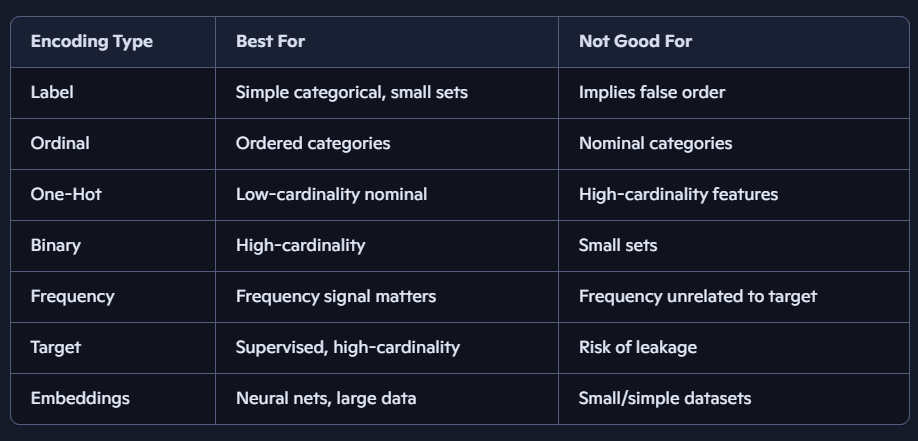